In [11]:
from plotnado import GenomicFigure, PlotStyle
import numpy as np
import pandas as pd

In [12]:
fig = GenomicFigure()
fig, locus = fig.from_igv_session('/Users/asmith/Desktop/igv_session_CAT_and_MPAL_v2.xml')

In [3]:
fig

#,Type,Title,Data,Height
0,ScaleBar,ScaleBar,,0.3
1,GenomicAxis,,,0.2
2,Genes,,,1.5
3,BigWigTrack,CAT-MV411_H3K27ac,/Users/asmith/Downloads/CAT-MV411_H3K27ac.bw,1.0
4,BigWigTrack,25_NK,/Users/asmith/Downloads/MPAL/25_NK.bw,1.0
5,BigWigTrack,24_CD8_CM,/Users/asmith/Downloads/MPAL/24_CD8_CM.bw,1.04
6,BigWigTrack,23_CD8_EM,/Users/asmith/Downloads/MPAL/23_CD8_EM.bw,1.0
7,BigWigTrack,22_CD4_M,/Users/asmith/Downloads/MPAL/22_CD4_M.bw,1.0
8,BigWigTrack,21_CD4_N2,/Users/asmith/Downloads/MPAL/21_CD4_N2.bw,1.0
9,BigWigTrack,20_CD4_N1,/Users/asmith/Downloads/MPAL/20_CD4_N1.bw,1.0


In [13]:
fig = fig.remove_track(1)
fig.autoscale()

#,Type,Title,Data,Height
0,ScaleBar,ScaleBar,,0.3
1,Genes,,,1.5
2,BigWigTrack,CAT-MV411_H3K27ac,/Users/asmith/Downloads/CAT-MV411_H3K27ac.bw,1.0
3,BigWigTrack,25_NK,/Users/asmith/Downloads/MPAL/25_NK.bw,1.0
4,BigWigTrack,24_CD8_CM,/Users/asmith/Downloads/MPAL/24_CD8_CM.bw,1.04
5,BigWigTrack,23_CD8_EM,/Users/asmith/Downloads/MPAL/23_CD8_EM.bw,1.0
6,BigWigTrack,22_CD4_M,/Users/asmith/Downloads/MPAL/22_CD4_M.bw,1.0
7,BigWigTrack,21_CD4_N2,/Users/asmith/Downloads/MPAL/21_CD4_N2.bw,1.0
8,BigWigTrack,20_CD4_N1,/Users/asmith/Downloads/MPAL/20_CD4_N1.bw,1.0
9,BigWigTrack,19_CD8_N,/Users/asmith/Downloads/MPAL/19_CD8_N.bw,1.0


In [15]:
fig.update_track(track_type="bigwig", height=0.22, style=PlotStyle.FRAGMENT, color="#374151")
fig.update_track("CAT-MV411_H3K27ac", color="#d9485f", height=0.32)
fig.update_track(track_type="scalebar", height=0.18)
fig.update_track(track_type="genes", height=0.55)

#,Type,Title,Data,Height
0,ScaleBar,ScaleBar,,0.18
1,Genes,,,0.55
2,BigWigTrack,CAT-MV411_H3K27ac,/Users/asmith/Downloads/CAT-MV411_H3K27ac.bw,0.32
3,BigWigTrack,25_NK,/Users/asmith/Downloads/MPAL/25_NK.bw,0.22
4,BigWigTrack,24_CD8_CM,/Users/asmith/Downloads/MPAL/24_CD8_CM.bw,0.22
5,BigWigTrack,23_CD8_EM,/Users/asmith/Downloads/MPAL/23_CD8_EM.bw,0.22
6,BigWigTrack,22_CD4_M,/Users/asmith/Downloads/MPAL/22_CD4_M.bw,0.22
7,BigWigTrack,21_CD4_N2,/Users/asmith/Downloads/MPAL/21_CD4_N2.bw,0.22
8,BigWigTrack,20_CD4_N1,/Users/asmith/Downloads/MPAL/20_CD4_N1.bw,0.22
9,BigWigTrack,19_CD8_N,/Users/asmith/Downloads/MPAL/19_CD8_N.bw,0.22


In [10]:
# import pyranges1 as pr

# gr = pr.PyRanges(dict(Chromosome=['chr5'], Start=[2_013_400], End=[2_014_052]))

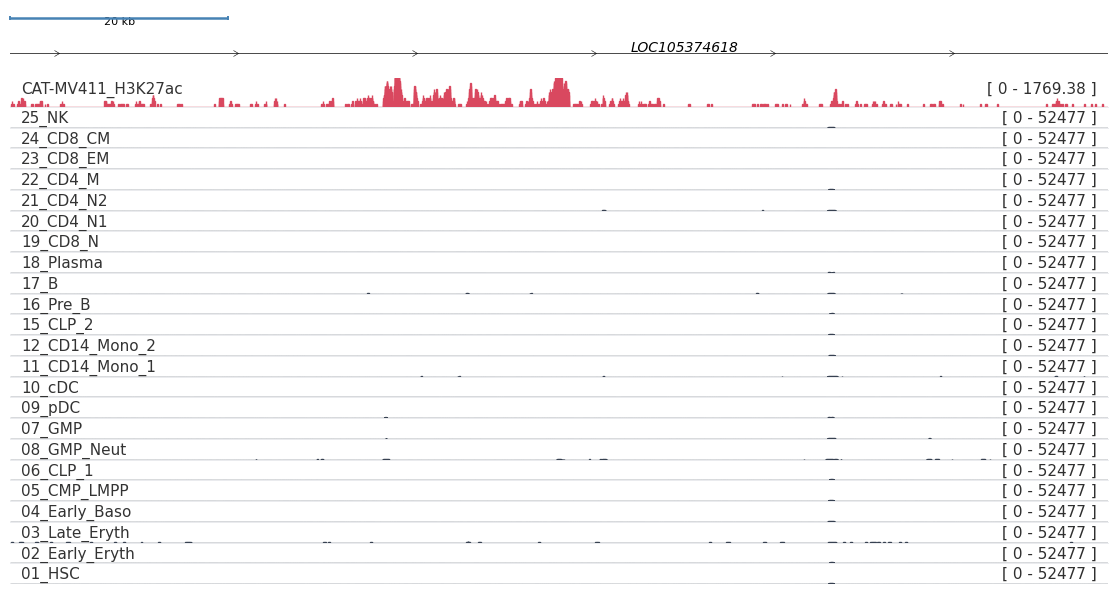

In [16]:
f = fig.plot('chr5:2,013,400-2,014,052', extend=50_000)
f

In [17]:
# Set svg style for editing in Inkscape
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['svg.hashsalt'] = 'mv411_trancer'
f.savefig('mv411_trancer.svg', bbox_inches='tight')

## Worked examples

Start with file-backed examples, since that is the main PlotNado workflow in practice. These examples use public BigWig signal tracks from the Blueprint human hub at `https://ftp.ebi.ac.uk/pub/databases/blueprint/releases/current_release/homo_sapiens/hub/hub.txt`, so they require network access.

In [9]:
from pathlib import Path
import plotnado

from plotnado import GenomicFigure, PlotStyle

rna_gene_of_interest = "ACTB"
monocyte_gene_of_interest = "LYZ"
repo_root = Path(plotnado.__file__).resolve().parent.parent
blueprint_bigwig_files = {
    "T12-15 plasma cell RNA": "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/tonsil/T12-15/plasma_cell/RNA-Seq/IDIBAPS/T12-15-PC.signal.star_grape2_crg.GRCh38.20150815.bw",
    "T12-16 plasma cell RNA": "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/tonsil/T12-16/plasma_cell/RNA-Seq/IDIBAPS/T12-16-PC.signal.star_grape2_crg.GRCh38.20150815.bw",
}
blueprint_monocyte_h3k27ac_signal = "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/venous_blood/C000S5/CD14-positive_CD16-negative_classical_monocyte/ChIP-Seq/NCMLS/C000S5H2.ERX173536.H3K27ac.bwa.GRCh38.20150529.bw"
blueprint_monocyte_h3k27ac_peaks = "http://ftp.ebi.ac.uk/pub/databases/blueprint/data/homo_sapiens/GRCh38/venous_blood/C000S5/CD14-positive_CD16-negative_classical_monocyte/ChIP-Seq/NCMLS/C000S5H2.ERX173536.H3K27ac.bwa.GRCh38.20150527.bb"
blueprint_monocyte_candidate_bed = repo_root / "examples" / "data" / "blueprint_monocyte_lyz_candidate_peaks.bed"

### Example 1: stacked Blueprint BigWig tracks with label boxes

This mirrors the main workflow closely: two real Blueprint RNA BigWig files, separate panels, and the track title and scale drawn inside the plotted area with a visible background box.

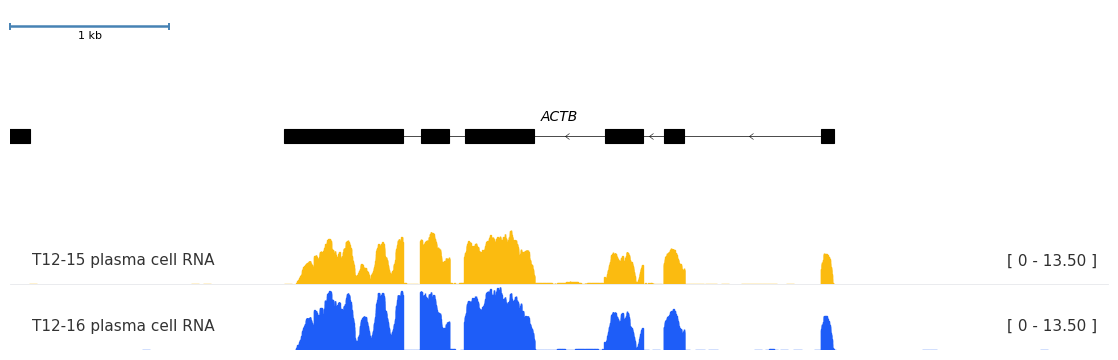

In [18]:
stacked_fig = GenomicFigure()
stacked_fig.scalebar()
stacked_fig.genes("hg38")
stacked_fig.autocolor()

for name, url in blueprint_bigwig_files.items():
    stacked_fig.bigwig(
        url,
        title=name,
        style=PlotStyle.FRAGMENT,
        height=0.55,
        autoscale_group="blueprint_rna",
        label_on_track=True,
        label_box_enabled=True,
        label_box_alpha=0.95,
        title_height=0.5,
        scale_height=0.5,
        plot_scale=True,
    )

stacked_plot = stacked_fig.plot_gene(rna_gene_of_interest)
stacked_plot

### Example 2: Blueprint `bigwig_overlay()` with a shared axis

`bigwig_overlay()` is the clearer API for this case. It resolves to the same implementation as `overlay()`, but the current implementation auto-wraps path inputs as `BigWigTrack`, so the more specific name matches the actual behavior better.

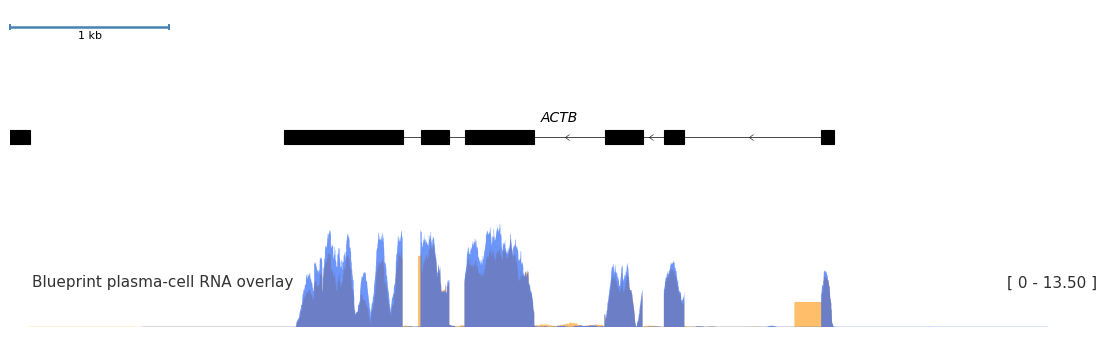

In [19]:
overlay_fig = GenomicFigure()
overlay_fig.scalebar()
overlay_fig.genes("hg38")
overlay_fig.bigwig_overlay(
    list(blueprint_bigwig_files.values()),
    title="Blueprint plasma-cell RNA overlay",
    colors=["#FF9D1B", "#1E5DF8"],
    alpha=0.65,
    height=0.9,
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.5,
    scale_height=0.5,
    plot_scale=True,
)

overlay_plot = overlay_fig.plot_gene(rna_gene_of_interest)
overlay_plot

### Example 3: a real review plot with Blueprint `BigWig`, Blueprint `bigBed`, and a checked-in `BED`

This mirrors a more realistic workflow: inspect a public signal track, compare it to the hub's peak calls, and add a checked-in BED file that captures the loci you want to revisit after review.

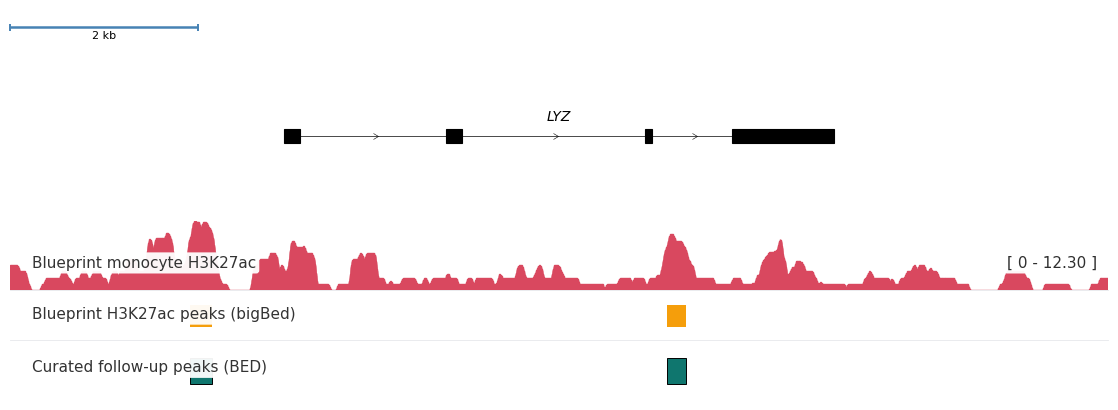

In [20]:
review_fig = GenomicFigure()
review_fig.scalebar()
review_fig.genes("hg38")
review_fig.bigwig(
    blueprint_monocyte_h3k27ac_signal,
    title="Blueprint monocyte H3K27ac",
    style=PlotStyle.FRAGMENT,
    height=0.6,
    color="#d9485f",
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.5,
    scale_height=0.5,
    plot_scale=True,
)
review_fig.bed(
    blueprint_monocyte_h3k27ac_peaks,
    title="Blueprint H3K27ac peaks (bigBed)",
    color="#f59e0b",
    draw_edges=False,
    height=0.42,
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.7,
    show_labels=False,
)
review_fig.bed(
    str(blueprint_monocyte_candidate_bed),
    title="Curated follow-up peaks (BED)",
    color="#0f766e",
    draw_edges=True,
    show_labels=True,
    label_field="name",
    font_size=7,
    height=0.5,
    label_on_track=True,
    label_box_enabled=True,
    label_box_alpha=0.95,
    title_height=0.7,
)

review_plot = review_fig.plot_gene(monocyte_gene_of_interest)
review_plot